In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nakullimbani30","key":"828d2b6396d9bef183918b5694e37989"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')


In [4]:
!pip install kaggle


In [5]:
!kaggle datasets download -d wcukierski/enron-email-dataset


Dataset URL: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset
License(s): copyright-authors
enron-email-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [6]:
!unzip enron-email-dataset.zip -d enron_email_data


Archive:  enron-email-dataset.zip
replace enron_email_data/emails.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: enron_email_data/emails.csv  


In [7]:
import pandas as pd
df = pd.read_csv('enron_email_data/emails.csv')  # Adjust path if necessary
print(df.head())


                       file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <24216240.1075855687451.JavaMail.e...
3  allen-p/_sent_mail/1000.  Message-ID: <13505866.1075863688222.JavaMail.e...
4  allen-p/_sent_mail/1001.  Message-ID: <30922949.1075863688243.JavaMail.e...


In [8]:
# prompt: print size and features of dataset

import pandas as pd

# Assuming 'df' is your DataFrame (loaded as shown in your example)
print("Dataset size (rows, columns):", df.shape)
print("\nFeatures (column names):\n", df.columns.tolist())
print("\nData types of each feature:\n", df.dtypes)
print("\nDescriptive statistics:\n", df.describe(include='all')) # Include all data types for statistics

# Example of looking at the first few rows of specific columns
print("\nFirst 5 rows of specific features:")
print(df[['file', 'message']].head())  # Replace with the columns you want to see


Dataset size (rows, columns): (517401, 2)

Features (column names):
 ['file', 'message']

Data types of each feature:
 file       object
message    object
dtype: object

Descriptive statistics:
                              file  \
count                      517401   
unique                     517401   
top     zufferli-j/sent_items/99.   
freq                            1   

                                                  message  
count                                              517401  
unique                                             517401  
top     Message-ID: <28618979.1075842030037.JavaMail.e...  
freq                                                    1  

First 5 rows of specific features:
                       file                                            message
0     allen-p/_sent_mail/1.  Message-ID: <18782981.1075855378110.JavaMail.e...
1    allen-p/_sent_mail/10.  Message-ID: <15464986.1075855378456.JavaMail.e...
2   allen-p/_sent_mail/100.  Message-ID: <2421

In [9]:
df[['file', 'message']].head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [10]:
df.head()

,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


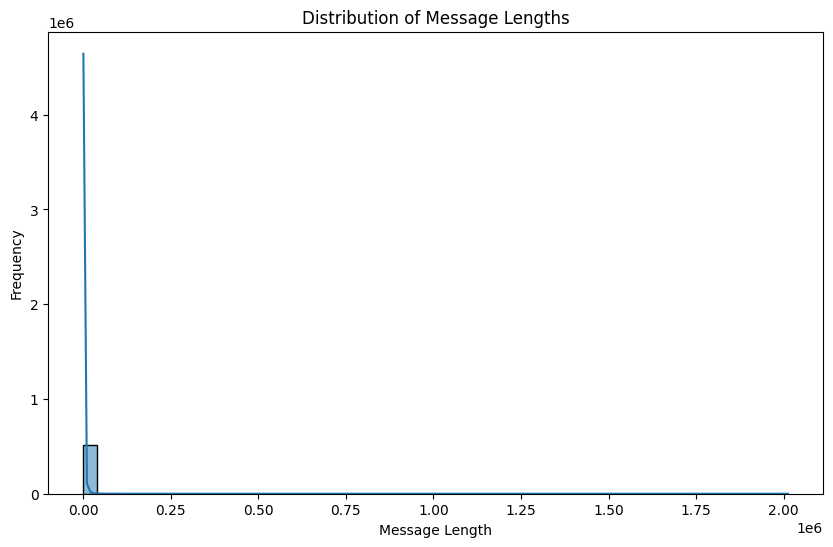

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Message Lengths
df['message_length'] = df['message'].astype(str).apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df['message_length'], bins=50, kde=True)
plt.title('Distribution of Message Lengths')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

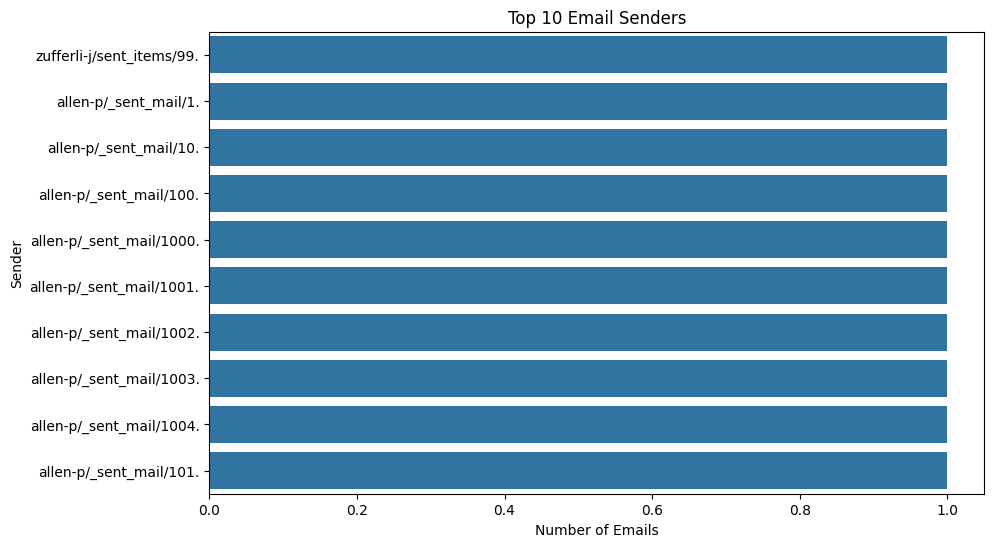

In [12]:
# 2. Top Senders
top_senders = df['file'].value_counts().nlargest(10)  # Adjust the number of top senders
plt.figure(figsize=(10, 6))
sns.barplot(x=top_senders.values, y=top_senders.index)
plt.title('Top 10 Email Senders')
plt.xlabel('Number of Emails')
plt.ylabel('Sender')
plt.show()

In [13]:
"""import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Reload the DataFrame
df = pd.read_csv('enron_email_data/emails.csv')  # Adjust path if necessary

# 3. Example: Word Cloud (if you have a 'message' column with text data)
# Combine all messages into a single string
text = ' '.join(df['message'].astype(str)) # ensures no error for non-string messages

# Create and generate a word cloud image:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()"""

'import pandas as pd\nfrom wordcloud import WordCloud\nimport matplotlib.pyplot as plt\n\n# Reload the DataFrame\ndf = pd.read_csv(\'enron_email_data/emails.csv\')  # Adjust path if necessary\n\n# 3. Example: Word Cloud (if you have a \'message\' column with text data)\n# Combine all messages into a single string\ntext = \' \'.join(df[\'message\'].astype(str)) # ensures no error for non-string messages\n\n# Create and generate a word cloud image:\nwordcloud = WordCloud(width=800, height=400, background_color=\'white\').generate(text)\nplt.figure(figsize=(10, 6))\nplt.imshow(wordcloud, interpolation=\'bilinear\')\nplt.axis("off")\nplt.show()'

In [14]:
import re
import numpy as np

# Function to clean the text (removing non-alphabet characters and converting to lowercase)
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabet characters
    text = text.lower()  # Convert to lowercase
    return text

# Apply the cleaning function to the 'message' column
df['cleaned_message'] = df['message'].apply(clean_text)

# Join all cleaned messages into a single text corpus
corpus = ' '.join(df['cleaned_message'].values)
print("Sample of cleaned corpus:", corpus[:500])  # Display a portion of the cleaned text


Sample of cleaned corpus: messageid javamailevansthyme
date mon  may    pdt
from phillipallenenroncom
to timbeldenenroncom
subject 
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding bit
xfrom phillip k allen
xto tim belden tim beldenenronenronxgate
xcc 
xbcc 
xfolder phillipallenjanallen phillip ksent mail
xorigin allenp
xfilename pallen nonprivilegedpst

here is our forecast

  messageid javamailevansthyme
date fri  may    pdt
from phillipallenenroncom
to johnlavoratoenroncom
subject re
mimeversi


In [15]:
from google.colab import files
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import numpy as np
import zipfile

# Create a zip file
zip_filename = 'cleaned_enron_data.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    # Add the cleaned DataFrame to the zip file
    df.to_csv('cleaned_emails.csv', index=False)  # Save the DataFrame as a CSV
    zipf.write('cleaned_emails.csv')

# Download the zip file
files.download(zip_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Assuming 'df' is your DataFrame (as in the provided code) and 'cleaned_message' column is created

# Save the DataFrame with the 'cleaned_message' column to a CSV file
df.to_csv('cleaned_enron_emails.csv', index=False)  # Save to the Colab environment

# Download the file to your local system
files.download('cleaned_enron_emails.csv')


In [17]:
corpus = corpus[:400000]

In [18]:
import tensorflow as tf
# Create a set of all unique characters in the corpus
chars = sorted(list(set(corpus)))
char_to_int = {ch: i for i, ch in enumerate(chars)}  # Map char to int
int_to_char = {i: ch for i, ch in enumerate(chars)}  # Map int to char

# Prepare the input and output sequences
sequence_length = 50  # Number of previous characters to predict the next one
X = []
y = []

for i in range(0, len(corpus) - sequence_length, 1):
    seq_in = corpus[i:i + sequence_length]  # Input sequence
    seq_out = corpus[i + sequence_length]  # Output (next character)
    X.append([char_to_int[char] for char in seq_in])  # Map chars to integers
    y.append(char_to_int[seq_out])

# Reshape X to be in the form [samples, time steps, features]
X = np.reshape(X, (len(X), sequence_length, 1))
X = X / float(len(chars))  # Normalize input data

# One-hot encode the output labels (next character)
y = tf.keras.utils.to_categorical(y, num_classes=len(chars))

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (399950, 50, 1)
Shape of y: (399950, 29)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Build the updated LSTM model
model = Sequential()

# Bidirectional LSTM layer (Capturing both past and future context)
model.add(Bidirectional(LSTM(512, return_sequences=True), input_shape=(X.shape[1], X.shape[2])))
model.add(Dropout(0.3))  # Increased dropout for regularization

# Second LSTM layer with more units
model.add(LSTM(512))
model.add(Dropout(0.3))  # Dropout layer to avoid overfitting

# Dense layer for output with softmax activation (for multi-class classification)
model.add(Dense(len(chars), activation='softmax'))

# Compile the model with a learning rate in the Adam optimizer
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001))

# Print the model summary to check architecture
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 50, 1024)            │       2,105,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 1024)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 512)                 │       3,147,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 29)                  │          14,877 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,267,997 (20.10 MB)

 Trainable params: 5,267,997 (20.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 249s 78ms/step - loss: 2.8034
Epoch 2/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 247s 79ms/step - loss: 1.7065
Epoch 3/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 247s 79ms/step - loss: 1.4466
Epoch 4/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 262s 79ms/step - loss: 1.2821
Epoch 5/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 263s 80ms/step - loss: 1.1578
Epoch 6/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 248s 79ms/step - loss: 1.0691
Epoch 7/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 247s 79ms/step - loss: 0.9942
Epoch 8/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 248s 79ms/step - loss: 0.9379
Epoch 9/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 262s 79ms/step - loss: 0.8902
Epoch 10/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 262s 79ms/step - loss: 0.8490
Epoch 11/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 263s 80ms/step - loss: 0.8110
Epoch 12/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 248s 79ms/step - loss: 0.7814
Epoch 13/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 248s 79ms/step - loss: 0.7535
Epoch 14/50
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 249s 80ms/step - 

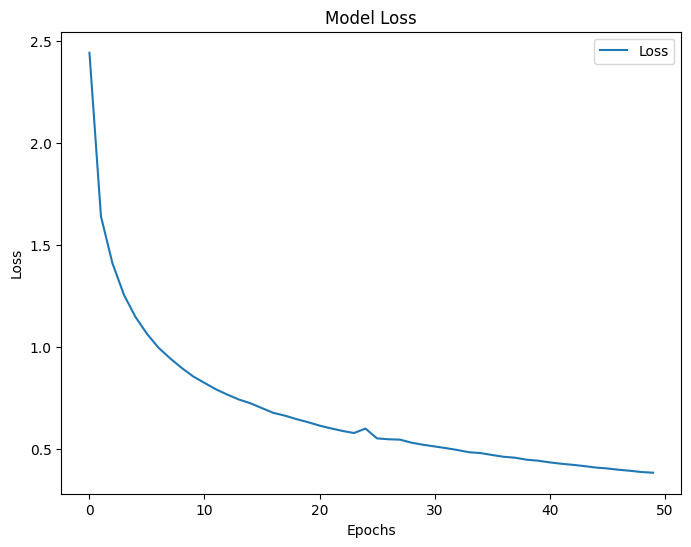

In [20]:
# Train the model
history = model.fit(X, y, epochs=50, batch_size=128, verbose=1)

# Plot the training loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [21]:
# Save the trained model
model.save('email_generator_model.h5')
print("Model saved successfully!")


Model saved successfully!


In [24]:
# Function to generate text
# Function to generate text
def generate_text(model, seed_text, num_chars=500):
    result = seed_text
    for _ in range(num_chars):
        # Filter seed_text to only include characters in char_to_int
        filtered_seed_text = "".join([char for char in seed_text[-sequence_length:] if char in char_to_int])

        X_pred = np.array([char_to_int[char] for char in filtered_seed_text])  # Use filtered seed text
        X_pred = np.reshape(X_pred, (1, len(X_pred), 1))
        X_pred = X_pred / float(len(chars))  # Normalize input

        predicted_probs = model.predict(X_pred, verbose=0)
        predicted_char_index = np.argmax(predicted_probs)  # Choose the most probable character
        predicted_char = int_to_char[predicted_char_index]

        result += predicted_char  # Append the predicted character to the result
        seed_text += predicted_char  # Add predicted character to seed for next prediction

    return result

# Test the model with a seed text
seed_text = "hello, i hope"
generated_text = generate_text(model, seed_text)
print("Generated Text:\n", generated_text)


Generated Text:
 hello, i hope mentia messageid javamailevansthyme
date tue  jul    pdt
from phillipallenenroncom
to jsmithaustintxcom
subject re the stage
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding bit
xfrom phillip k allen
xto mary richards maryrichardshotmailcom  enron
xcc 
xbcc 
xfolder phillipallendecnotes folderssent mail
xorigin allenp
xfilename pallennsf

 forwarded by phillip k allenhouect on  
 pm 
   
	enron north america corp
	
	from  kimberly hillis                              pm



In [25]:
import re

def postprocess_text(text):
    # 1. Add a period if the text doesn't end with a punctuation mark.
    if not text.endswith(('.', '!', '?')):
        text += '.'

    # 2. Fix any common incomplete sentence structures (e.g., missing 'I' or 'You')
    text = re.sub(r'(\b[A-Za-z]+)\s*(\d+)', r'\1 \2', text)  # Fix spacing issues

    # 3. Replace placeholders (or missing information) with actual content (if desired)
    text = text.replace('xxx', 'your contact number')  # Example: replace 'xxx' with actual data.

    return text

# Test postprocessing on the generated text
generated_text = "hello, i hope your of the loan remains in the builderdevelopers name"
processed_text = postprocess_text(generated_text)
print(processed_text)


hello, i hope your of the loan remains in the builderdevelopers name.


In [31]:
import numpy as np

def sample_with_temperature(preds, temperature=1.0):
    # Scale the predictions to adjust the randomness
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temperature
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)  # Normalize to get probabilities

    # Ensure preds is 1-dimensional
    preds = preds.flatten()  # Flatten the array to 1D

    return np.random.choice(len(preds), p=preds)


def generate_text_with_temperature(model, seed_text, num_chars=500, temperature=1.0):
    result = seed_text
    for _ in range(num_chars):
        # Prepare the prediction input
        # Filter seed_text to only include characters in char_to_int
        filtered_seed_text = "".join([char for char in seed_text[-sequence_length:] if char in char_to_int])

        X_pred = np.array([char_to_int[char] for char in filtered_seed_text])  # Use filtered seed text
        X_pred = np.reshape(X_pred, (1, len(X_pred), 1))
        X_pred = X_pred / float(len(chars))  # Normalize input

        predicted_probs = model.predict(X_pred, verbose=0)
        predicted_char_index = sample_with_temperature(predicted_probs, temperature)
        predicted_char = int_to_char[predicted_char_index]

        result += predicted_char
        seed_text += predicted_char

    return result

# Test the model with a seed text and temperature
generated_text = generate_text_with_temperature(model, seed_text="hello, i hope", num_chars=500, temperature=0.8)
print(generated_text)

hello, i hope ment be billion day  gavidir in grnwe be in linked to aeoron gor a than is notiin might be the addition of a configured by the buciagst of a burvre you on assumd that he paid to all a load instruction loan in the 
wear  ken wants to have this updated chart in his briefing book for nessageid javamailevansthyme
date fri  jun    pdt
from phillipallenenroncom
to stouchstonenatsourcecom
subject re unom ass nearian telleniiogs
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding 


In [27]:
# prompt: download above trained model in local machine as a zip file

from google.colab import files
import zipfile

# Create a zip file
zip_filename = 'email_generator_model.zip'
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write('email_generator_model.h5')

# Download the zip file
files.download(zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
zip_filename = 'cleaned_enron_data.zip'
# Download the zip file
files.download(zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
# Evaluate the model (example using perplexity)

# Assuming 'X' and 'y' are your test data (input and output sequences)

# Calculate the perplexity
loss = model.evaluate(X, y, verbose=0)
perplexity = np.exp(loss)

print(f"Test Loss: {loss}")
print(f"Perplexity: {perplexity}")



Test Loss: 0.17439435422420502
Perplexity: 1.1905249618078446


In [33]:
# prompt: evaluate the model with few inputs

# Example usage of generate_text_with_temperature with different temperatures
seed_text = "hello, i hope"

temperatures = [0.2, 0.5, 0.8, 1.0]
for temp in temperatures:
    generated_text = generate_text_with_temperature(model, seed_text, num_chars=200, temperature=temp)
    print(f"Generated text with temperature {temp}:\n{generated_text}\n")


# Evaluate with a different seed text
seed_text_2 = "Subject: Meeting"
generated_text_2 = generate_text_with_temperature(model, seed_text_2, num_chars=200, temperature=0.7)  # Example temperature
print(f"Generated text with seed '{seed_text_2}':\n{generated_text_2}")


Generated text with temperature 0.2:
hello, i hope mentia messageid javamailevansthyme
date tue  apr    pdt
from phillipallenenroncom
to jsmithaustintxcom
subject re resource
mimeversion 
contenttype textplain charsetusascii
contenttransferencoding b

Generated text with temperature 0.5:
hello, i hope ment m presenteoroenm

 for to thould you please expect that the republicans are not
sure it wery select that was prepared in the west desk
mimeversion 
contenttype textplain charsetusascii
contenttr

Generated text with temperature 0.8:
hello, i hope ment l put l has cutiness  in the finishings and choose a
builder
i just wanted to give you the optionalin of for all of the change
eliminate change deals by 


thank you think about the rise

      

Generated text with temperature 1.0:
hello, i hope y 
can you help
 please advise of somiing with them  more gas 
cetailed 
phillip messageid javamailevansthyme
date tue  jul    pdt
from phillipallenenroncom
to pallenhotmailcom
subject re strpr

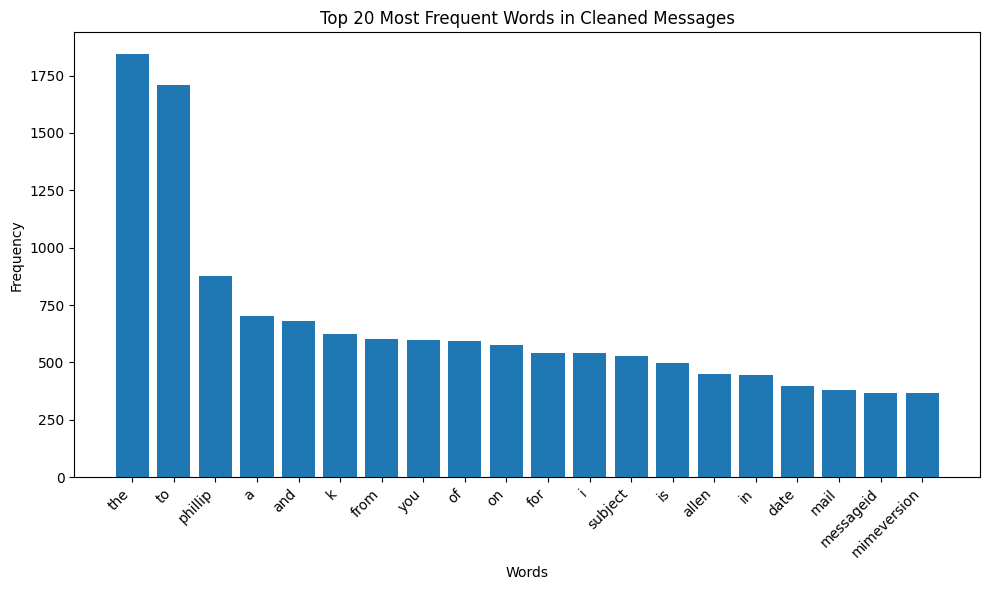

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

words = corpus.split()
word_counts = Counter(words)
top_words = word_counts.most_common(20)  # Get the top 20 most frequent words

plt.figure(figsize=(10,6))
plt.bar(*zip(*top_words))  # Efficient way to plot bars from counter data
plt.title('Top 20 Most Frequent Words in Cleaned Messages')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha="right") # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

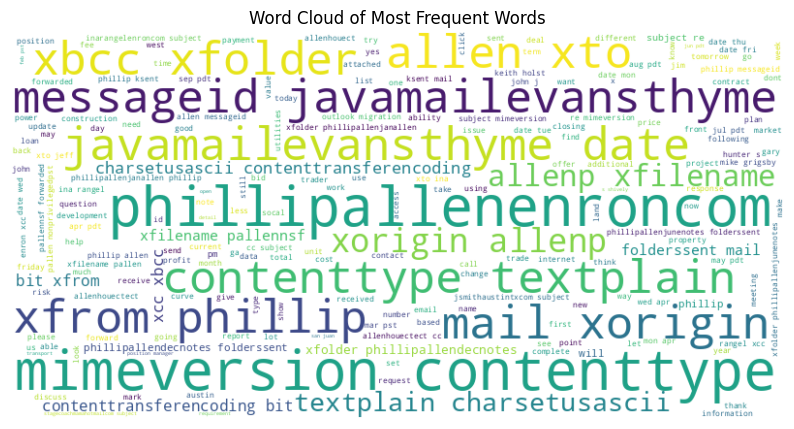

In [43]:
from wordcloud import WordCloud

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(corpus)

# Display the word cloud
plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off axis
plt.title('Word Cloud of Most Frequent Words')
plt.show()
